In [18]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import cv2

# Global variables
data_dir = 'P:/Windows/Desktop/EC9580_COMPUTER_VISION/archive (4)'
train_path = os.path.join(data_dir, 'Train')
IMG_HEIGHT, IMG_WIDTH, channels = 30, 30, 3
num_of_class = len(os.listdir(train_path))

In [4]:
def load_and_preprocess_train_data():
    image_data, image_labels = [], []
    for label in range(num_of_class):
        path = os.path.join(train_path, str(label))
        images = os.listdir(path)

        for img_name in images:
            try:
                image = Image.open(os.path.join(path, img_name)).convert('RGB')
                resized_image = image.resize((IMG_HEIGHT, IMG_WIDTH))
                image_data.append(np.array(resized_image))
                image_labels.append(label)
            except Exception as e:
                print(f"Error loading image {img_name}: {e}")

    image_data = np.array(image_data)
    image_labels = np.array(image_labels)
    return image_data, image_labels


In [5]:
def split_and_normalize_data(image_data, image_labels):
    shuffle_indexes = np.arange(len(image_data))
    np.random.shuffle(shuffle_indexes)
    image_data = image_data[shuffle_indexes] / 255.0
    image_labels = image_labels[shuffle_indexes]

    X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.3, random_state=42)
    return X_train, X_val, y_train, y_val


In [6]:
def build_cnn_model():
    model = Sequential([
        Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, channels)),
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(rate=0.5),
        Dense(num_of_class, activation='softmax')
    ])
    return model


In [7]:
def compile_and_train_model(model, X_train, y_train, X_val, y_val, learning_rate=0.001, epochs=10):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    # Data augmentation
    data_augmentor = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.15,
        fill_mode="nearest"
    )

    history = model.fit(
        data_augmentor.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=epochs
    )
    return model

In [8]:
image_data, image_labels = load_and_preprocess_train_data()
X_train, X_val, y_train, y_val = split_and_normalize_data(image_data, image_labels)
cnn_model = build_cnn_model()
trained_model = compile_and_train_model(cnn_model, X_train, y_train, X_val, y_val)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.4982 - loss: 2.0324 - val_accuracy: 0.9705 - val_loss: 0.1002
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9336 - loss: 0.2188 - val_accuracy: 0.9909 - val_loss: 0.0290
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9634 - loss: 0.1171 - val_accuracy: 0.9906 - val_loss: 0.0338
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9748 - loss: 0.0845 - val_accuracy: 0.9772 - val_loss: 0.0726
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9756 - loss: 0.0803 - val_accuracy: 0.9915 - val_loss: 0.0269
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9794 - loss: 0.0652 - val_accuracy: 0.9944 - val_loss: 0.0179
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9813 - loss: 0.0612 - val_accuracy: 0.9908 - val_loss: 0.0312
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.9833 - loss: 0.0528 - 

In [9]:
model_save_path = "traffic_sign_classifier.h5"
trained_model.save(model_save_path)

In [10]:
def evaluate_saved_model(model_path, test_data_path):
    test_data = pd.read_csv(os.path.join(test_data_path, 'Test.csv'))
    labels = test_data["ClassId"].values
    img_paths = test_data["Path"].values

    test_images = []
    for img_path in img_paths:
        try:
            image = Image.open(os.path.join(data_dir, img_path)).convert('RGB')
            resized_image = image.resize((IMG_HEIGHT, IMG_WIDTH))
            test_images.append(np.array(resized_image))
        except Exception as e:
            print(f"Error loading test image {img_path}: {e}")

    X_test = np.array(test_images) / 255.0

    model = load_model(model_path)
    predictions = model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predicted_classes)
    print(f"Test Data Accuracy: {accuracy * 100:.2f}%")


evaluate_saved_model(model_save_path, data_dir)

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Test Data Accuracy: 96.56%


In [26]:
evaluate_saved_model(model_save_path, data_dir)

395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Test Data Accuracy: 96.56%


In [14]:
classes = { 
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 
    2:'Speed limit (50km/h)', 3:'Speed limit (60km/h)', 
    4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)', 
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 
    8:'Speed limit (120km/h)', 9:'No passing', 
    10:'No passing veh over 3.5 tons', 
    11:'Right-of-way at intersection', 12:'Priority road', 
    13:'Yield', 14:'Stop', 15:'No vehicles', 
    16:'Veh > 3.5 tons prohibited', 17:'No entry', 
    18:'General caution', 19:'Dangerous curve left', 
    20:'Dangerous curve right', 21:'Double curve',  
    22:'Bumpy road', 23:'Slippery road', 
    24:'Road narrows on the right', 25:'Road work', 
    26:'Traffic signals', 27:'Pedestrians', 
    28:'Children crossing', 29:'Bicycles crossing', 
    30:'Beware of ice/snow', 31:'Wild animals crossing', 
    32:'End speed + passing limits', 33:'Turn right ahead', 
    34:'Turn left ahead', 35:'Ahead only', 
    36:'Go straight or right', 37:'Go straight or left', 
    38:'Keep right', 39:'Keep left', 
    40:'Roundabout mandatory', 41:'End of no passing', 
    42:'End no passing veh > 3.5 tons' 
}

In [16]:
def preprocess_image(user_image, img_height, img_width, contrast_factor=2.0):
    img = np.array(user_image)
    if img.ndim == 2 or img.shape[-1] != 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    denoised_img = cv2.GaussianBlur(img, (5, 5), 0)
    lab = cv2.cvtColor(denoised_img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.convertScaleAbs(l, alpha=contrast_factor, beta=0)
    lab = cv2.merge([l, a, b])
    enhanced_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    upscale_factor = 1.5 
    upscaled_img = cv2.resize(enhanced_img, None, fx=upscale_factor, fy=upscale_factor, interpolation=cv2.INTER_LINEAR)
    resized_img = cv2.resize(upscaled_img, (img_width, img_height))
    normalized_img = resized_img / 255.0
    input_img = np.expand_dims(normalized_img, axis=0)

    return input_img

def predict_traffic_sign(model_path, user_image, classes):
    model = load_model(model_path)
    preprocessed_img = preprocess_image(user_image, IMG_HEIGHT, IMG_WIDTH)
    predictions = model.predict(preprocessed_img)
    class_idx = np.argmax(predictions)

    return classes[class_idx]

In [40]:
user_image = Image.open("OIP1.jpg")
result = predict_traffic_sign("traffic_sign_classifier.h5", user_image, classes)
print("Predicted traffic sign:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Predicted traffic sign: Stop


In [33]:
def get_random_images_and_labels(test_data_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH, num_images=15):
    test_data = pd.read_csv(os.path.join(test_data_path, 'Test.csv'))
    labels = test_data["ClassId"].values
    img_paths = test_data["Path"].values

    random_indices = random.sample(range(len(img_paths)), num_images)
    random_images = []
    random_labels = []

    for idx in random_indices:
        try:
            img_path = img_paths[idx]
            label = labels[idx]
            image = Image.open(os.path.join(test_data_path, img_path)).convert('RGB')
            resized_image = image.resize((img_width, img_height))
            random_images.append(np.array(resized_image))
            random_labels.append(label)
        except Exception as e:
            print(f"Error loading image {img_paths[idx]}: {e}")

    random_images = np.array(random_images) / 255.0

    plt.figure(figsize=(15, 15))
    for i, img in enumerate(random_images):
        plt.subplot(3, 5, i + 1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])

        plt.imshow(img)
        plt.xlabel(f'Sign: {classes[random_labels[i]]}')

    plt.tight_layout()
    plt.show()


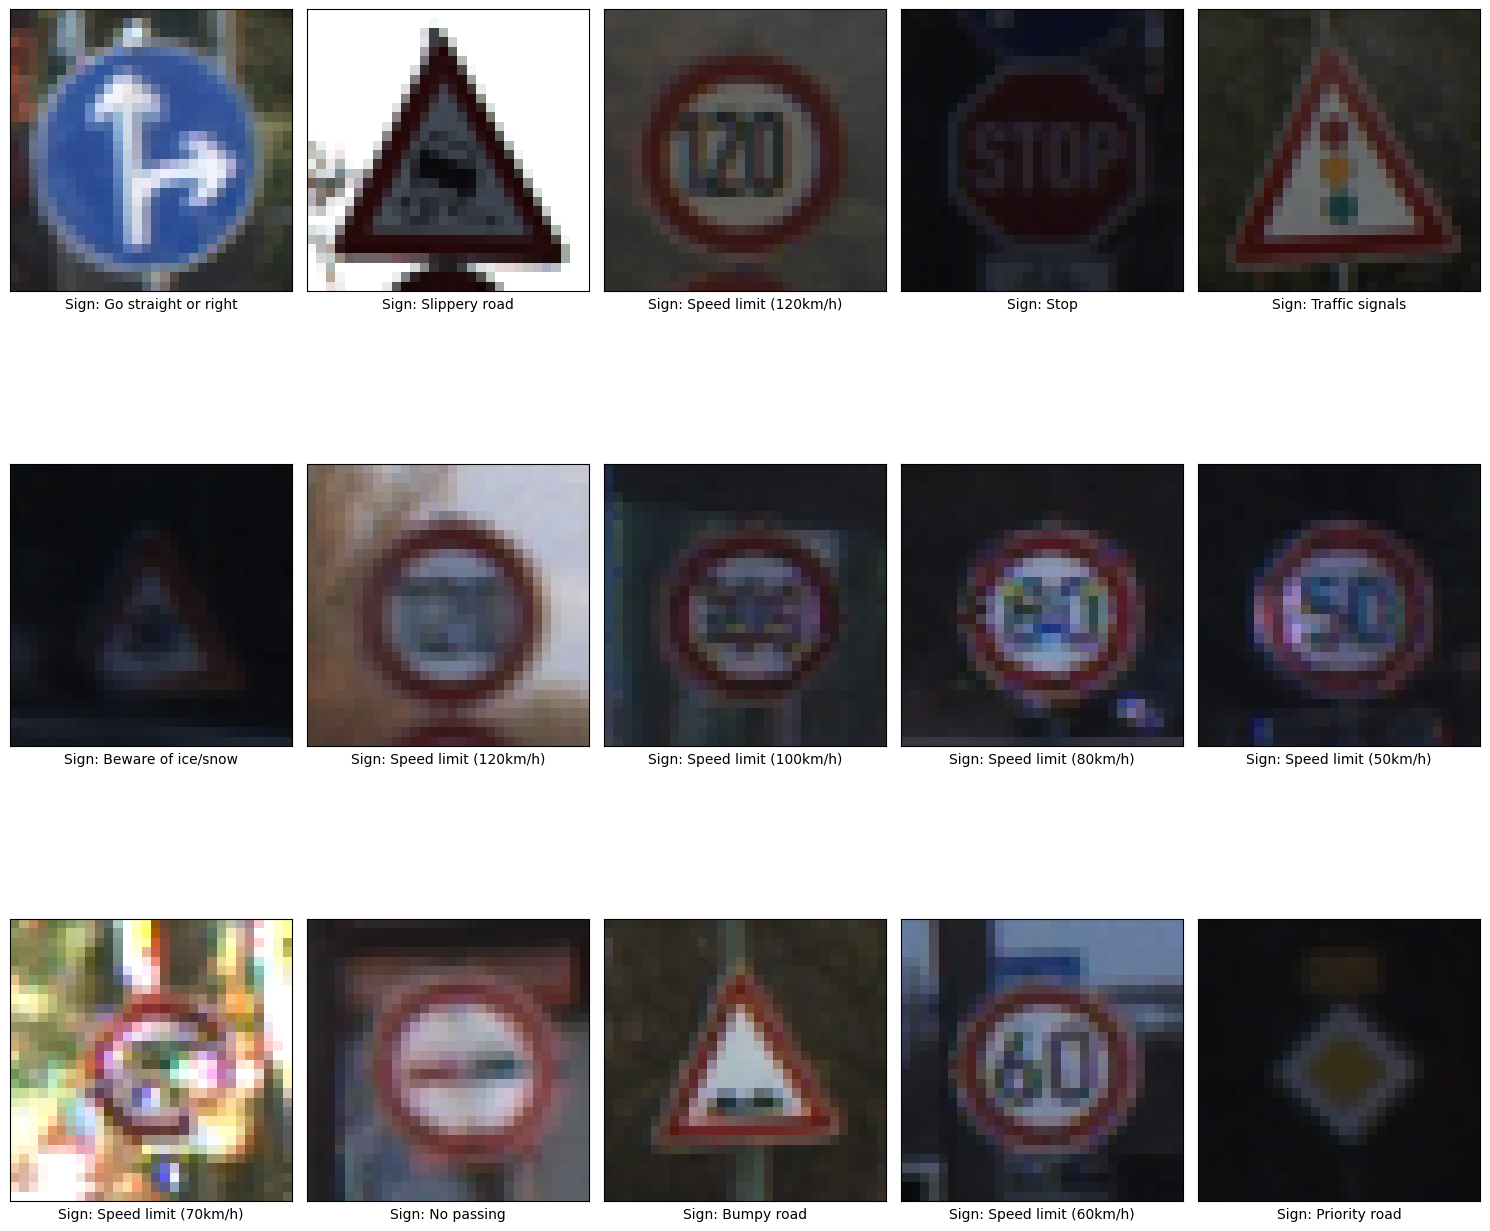

In [34]:
get_random_images_and_labels(data_dir, num_images=15)

In [46]:
def get_random_images_and_labels(test_data_path, model_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH, num_images=15):
    test_data = pd.read_csv(os.path.join(test_data_path, 'Test.csv'))
    labels = test_data["ClassId"].values
    img_paths = test_data["Path"].values

    random_indices = random.sample(range(len(img_paths)), num_images)
    random_images = []
    random_labels = []
    predicted_labels = []

    # Load the model once before the loop
    model = load_model(model_path)

    for idx in random_indices:
        try:
            img_path = img_paths[idx]
            label = labels[idx]
            image = Image.open(os.path.join(test_data_path, img_path)).convert('RGB')
            resized_image = image.resize((img_width, img_height))
            random_images.append(np.array(resized_image))
            random_labels.append(label)

            # Preprocess the image and make a prediction
            preprocessed_img = preprocess_image(image, img_height, img_width)
            predictions = model.predict(preprocessed_img)
            predicted_class_idx = np.argmax(predictions)
            predicted_labels.append(classes[predicted_class_idx])

        except Exception as e:
            print(f"Error loading image {img_paths[idx]}: {e}")

    random_images = np.array(random_images) / 255.0

    plt.figure(figsize=(15, 15))
    for i, img in enumerate(random_images):
        plt.subplot(3, 5, i + 1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])

        plt.imshow(img)
        plt.xlabel(f'Actual: {classes[random_labels[i]]}, \nPredicted: {predicted_labels[i]}')

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


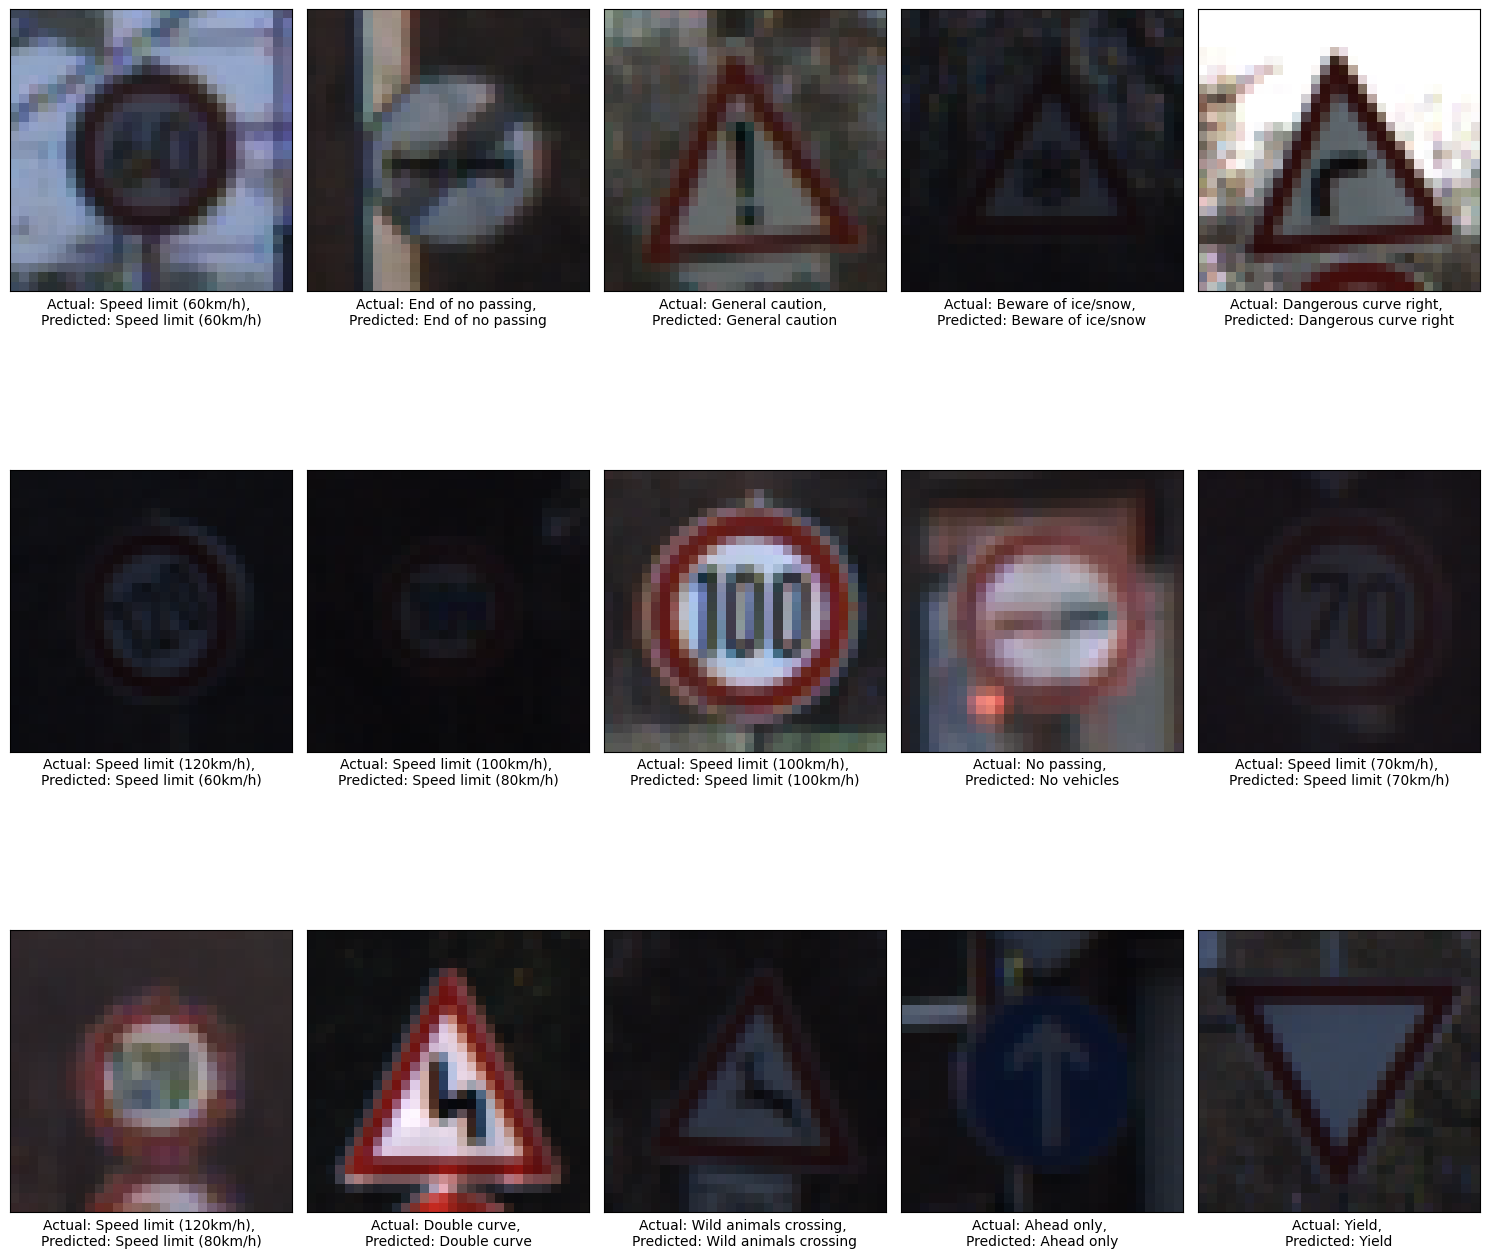

In [48]:
get_random_images_and_labels(data_dir,"traffic_sign_classifier.h5", num_images=15)

Captured Image:


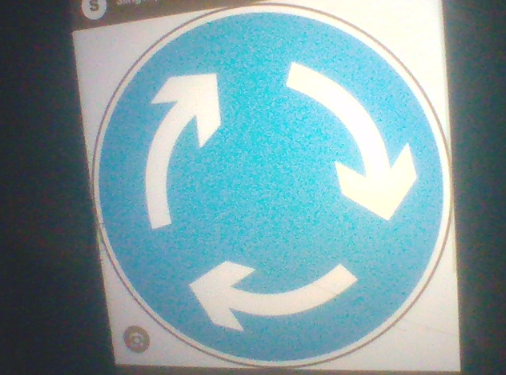

Input Image for Prediction (Resized and Preprocessed):


Prediction: Roundabout mandatory
Exit


In [30]:
from IPython.display import display, clear_output
import time

def capture_and_predict_with_input_display(model_path, classes, img_height=30, img_width=30, capture_interval=2):
    model = load_model(model_path)
    cap = cv2.VideoCapture(0) 

    if not cap.isOpened():
        print("Error: Could not open camera.")
        return

    try:
        while True:
            start_time = time.time()
            ret, frame = cap.read()
            if not ret:
                print("Error: Unable to capture frame.")
                break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_frame)

            img = cv2.resize(frame, (img_width, img_height))
            normalized_img = img / 255.0
            input_img = np.expand_dims(normalized_img, axis=0)

            predictions = model.predict(input_img)
            class_idx = np.argmax(predictions)
            class_name = classes[class_idx]

            clear_output(wait=True)
            print("Captured Image:")
            display(pil_img)

            input_img_display = (normalized_img * 255).astype(np.uint8)
            input_pil_img = Image.fromarray(cv2.cvtColor(input_img_display, cv2.COLOR_BGR2RGB))
            print("Input Image for Prediction (Resized and Preprocessed):")
            display(input_pil_img)

            print(f"Prediction: {class_name}")

            elapsed_time = time.time() - start_time
            time_to_wait = capture_interval - elapsed_time
            if time_to_wait > 0:
                time.sleep(time_to_wait)

    except KeyboardInterrupt:
        print("Exit")

    finally:
        cap.release()
        cv2.destroyAllWindows()

capture_and_predict_with_input_display("traffic_sign_classifier.h5", classes)
